EXERCISE 1: Max-Cut on this graph (5 nodes, 6 edges):

Edges: (0,1), (0,2), (1,2), (1,3), (2,4), (3,4)

(This is two overlapping triangles sharing an edge — asymmetric enough to be a real test, small enough to brute-force.)

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()


In [7]:
G.add_nodes_from([0, 1, 2, 3, 4])
G.add_edges_from([(0,1), (0,2), (1,2), (1,3), (2,4), (3,4)])

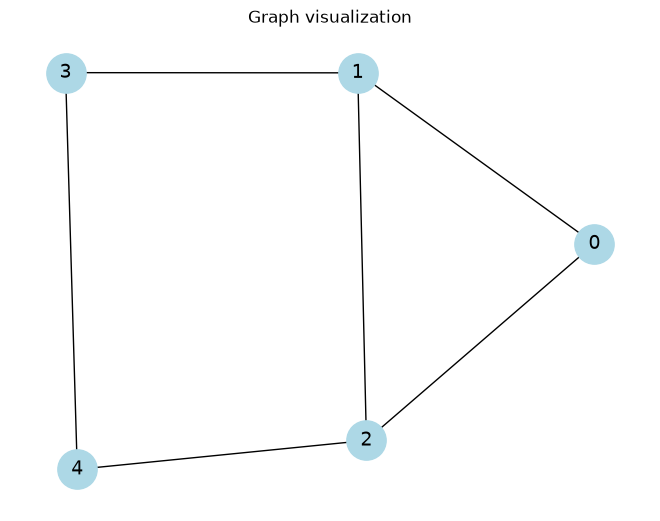

In [10]:
pos = nx.spring_layout(G, seed=42)  
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=14)
plt.title("Graph visualization")
plt.show()

# BRUTE FORCE SOLUTION

In [18]:
import numpy as np
def find_max(list):
    max = 0
    output = ""
    for element, value in list:
        if max < element:
            max = element
            output = value
    return [max, output]


def build_profile(number):
    list = []
    for case in range(2**number):
        bitstring = np.binary_repr(
            case, number
        )
        list.append(bitstring)
    return list

def calculate_output(string):
    x = []
    for char in string:
        if char == "0":
            x.append(-1)
        else:
            x.append(1)
    return 1/2*(6 - x[0]*x[1] - x[1]*x[2] - x[0]*x[2] - x[1]*x[3] - x[2]*x[4] - x[3]*x[4])

def final(num):
    list = []
    bitstrings = build_profile(num)
    for bitstring in bitstrings:
        list.append([calculate_output(bitstring), bitstring])
    return find_max(list)

final(5)
    

[5.0, '00110']

# NOW GOING TO THE QAOA IMPLEMENTATION

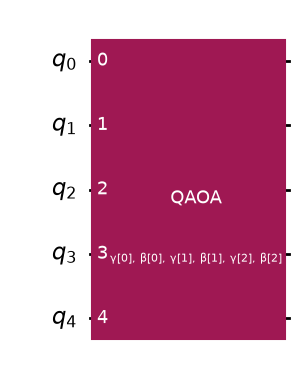

In [29]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
np.random.seed(0)


H = SparsePauliOp.from_sparse_list(
    [
        ("ZZ", [0, 1], -0.5),
        ("ZZ", [1, 2], -0.5),
        ("ZZ", [0, 2], -0.5),
        ("ZZ", [1, 3], -0.5),
        ("ZZ", [2, 4], -0.5),
        ("ZZ", [3, 4], -0.5),
    ],
    num_qubits=5
)

ansatz = QAOAAnsatz(cost_operator=H, reps=3)
x0 = np.random.uniform(0, 2*np.pi, ansatz.num_parameters) 
ansatz.draw(output = "mpl")




In [33]:
estimator = StatevectorEstimator() 
def cost_function(params, ansatz, hamiltonian): 
    pub = (ansatz, [hamiltonian], [params]) 
    result = estimator.run([pub]).result() 
    return result[0].data.evs[0]


result = minimize(cost_function, x0, args=(ansatz, H), method='COBYLA')
print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.1212217082444695
       x: [ 3.379e+00  4.484e+00  3.530e+00  3.485e+00  3.752e+00
            4.703e+00]
    nfev: 266
   maxcv: 0.0


In [39]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
optimized_circuit = ansatz.assign_parameters(result.x)
optimized_circuit.measure_all()

job = sampler.run([optimized_circuit], shots=1000)
counts = job.result()[0].data.meas.get_counts()

# find the best (lowest-energy) bitstring actually sampled
best_bitstring = max(counts, key=lambda b: calculate_output(b))
print("best sampled bitstring:", best_bitstring, "energy:", calculate_output(best_bitstring))



best sampled bitstring: 01001 energy: 5.0


/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
